# Challenge 02 — Regresión: Consumo Eléctrico de Planta Siderúrgica

**Variable objetivo:** `Usage_kWh`  
**Estrategia de validación:** Split temporal (~20 octubre 2018)

---
## Sección 1 — Setup & Load

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100

DATA_PATH = Path("train.csv")

In [2]:
df: pd.DataFrame = pd.read_csv(DATA_PATH)

print(f"Shape: {df.shape}")
print("\nDtypes:")
print(df.dtypes)
print("\nPrimeras 5 filas:")
df.head()

Shape: (28032, 10)

Dtypes:
date                                        str
Usage_kWh                               float64
Lagging_Current_Reactive.Power_kVarh    float64
Leading_Current_Reactive_Power_kVarh    float64
Lagging_Current_Power_Factor            float64
Leading_Current_Power_Factor            float64
NSM                                       int64
WeekStatus                                  str
Day_of_week                                 str
Load_Type                                   str
dtype: object

Primeras 5 filas:


,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
0,01/01/2018 00:00,3.42,3.46,0.0,70.30,100.0,0,Weekday,Monday,Light_Load
1,01/01/2018 00:15,3.17,2.95,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
2,01/01/2018 00:30,4.00,4.46,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load
3,01/01/2018 00:45,3.24,3.28,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load
4,01/01/2018 01:00,3.31,3.56,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load


---
## Sección 2 — Data Quality

In [3]:
null_counts: pd.Series = df.isnull().sum()
print("Nulos por columna:")
print(null_counts[null_counts > 0] if null_counts.sum() > 0 else "Sin valores nulos")

dup_count: int = df.duplicated().sum()
print(f"\nFilas duplicadas: {dup_count}")

Nulos por columna:
Sin valores nulos

Filas duplicadas: 0


In [4]:
categorical_cols: list[str] = ["WeekStatus", "Day_of_week", "Load_Type"]

for col in categorical_cols:
    if col in df.columns:
        print(f"\n{col} — {df[col].nunique()} valores únicos:")
        print(df[col].value_counts())


WeekStatus — 2 valores únicos:
WeekStatus
Weekday    20160
Weekend     7872
Name: count, dtype: int64

Day_of_week — 7 valores únicos:
Day_of_week
Monday       4032
Tuesday      4032
Wednesday    4032
Thursday     4032
Friday       4032
Saturday     3936
Sunday       3936
Name: count, dtype: int64

Load_Type — 3 valores únicos:
Load_Type
Light_Load      14368
Medium_Load      7808
Maximum_Load     5856
Name: count, dtype: int64


---
## Sección 3 — Target Analysis (Usage_kWh)

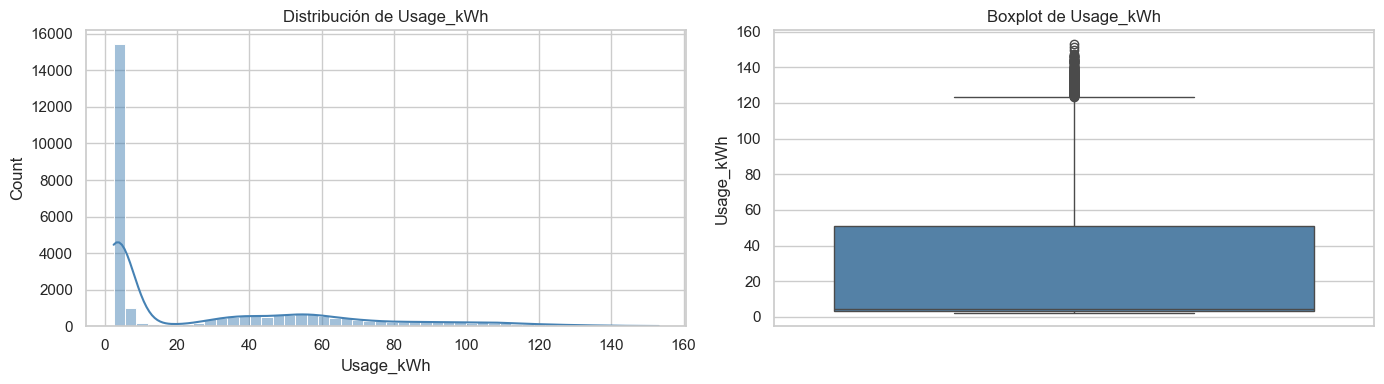

In [5]:
target: pd.Series = df["Usage_kWh"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram + KDE
sns.histplot(target, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribución de Usage_kWh")
axes[0].set_xlabel("Usage_kWh")

# Boxplot
sns.boxplot(y=target, ax=axes[1], color="steelblue")
axes[1].set_title("Boxplot de Usage_kWh")

plt.tight_layout()
plt.show()

In [6]:
skewness: float = float(target.skew())

print("Estadísticas de Usage_kWh:")
print(f"  Media:    {target.mean():.2f}")
print(f"  Std:      {target.std():.2f}")
print(f"  Min:      {target.min():.2f}")
print(f"  Max:      {target.max():.2f}")
print(f"  Mediana:  {target.median():.2f}")
print(f"  Skewness: {skewness:.4f}")

Estadísticas de Usage_kWh:
  Media:    27.93
  Std:      33.92
  Min:      2.45
  Max:      153.14
  Mediana:  4.61
  Skewness: 1.1812


---
## Sección 4 — Date Column Analysis

In [7]:
df["date"] = pd.to_datetime(df["date"], dayfirst=True)

df["hour"] = df["date"].dt.hour
df["day_of_month"] = df["date"].dt.day
df["month"] = df["date"].dt.month
df["day_of_week_num"] = df["date"].dt.dayofweek

print("Rango de fechas:")
print(f"  Inicio: {df['date'].min()}")
print(f"  Fin:    {df['date'].max()}")

Rango de fechas:
  Inicio: 2018-01-01 00:00:00
  Fin:    2018-10-19 23:45:00


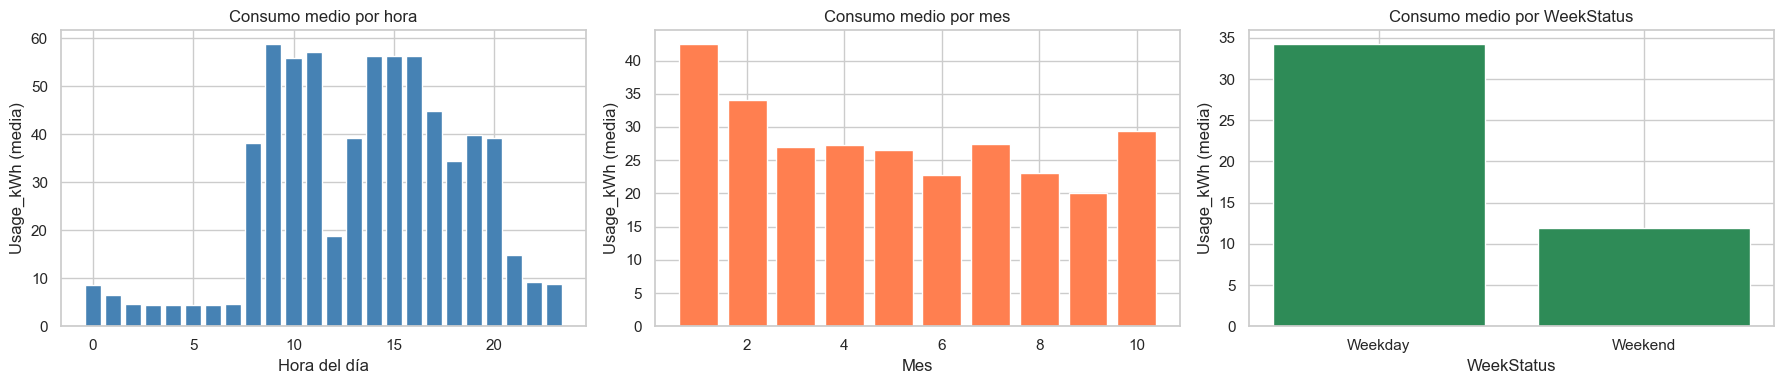

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Consumo medio por hora
hourly_mean: pd.Series = df.groupby("hour")["Usage_kWh"].mean()
axes[0].bar(hourly_mean.index, hourly_mean.values, color="steelblue")
axes[0].set_title("Consumo medio por hora")
axes[0].set_xlabel("Hora del día")
axes[0].set_ylabel("Usage_kWh (media)")

# Consumo medio por mes
monthly_mean: pd.Series = df.groupby("month")["Usage_kWh"].mean()
axes[1].bar(monthly_mean.index, monthly_mean.values, color="coral")
axes[1].set_title("Consumo medio por mes")
axes[1].set_xlabel("Mes")
axes[1].set_ylabel("Usage_kWh (media)")

# Consumo por WeekStatus
if "WeekStatus" in df.columns:
    weekstatus_mean: pd.Series = df.groupby("WeekStatus")["Usage_kWh"].mean()
    axes[2].bar(weekstatus_mean.index, weekstatus_mean.values, color="seagreen")
    axes[2].set_title("Consumo medio por WeekStatus")
    axes[2].set_xlabel("WeekStatus")
    axes[2].set_ylabel("Usage_kWh (media)")

plt.tight_layout()
plt.show()

### Conclusión — Patrones temporales

La columna `date` revela patrones claros de consumo:

- **Por hora:** el consumo sube durante el horario laboral (aprox. 8h–18h) y cae en la madrugada, reflejando turnos de producción.
- **Por mes:** se observan variaciones estacionales que pueden relacionarse con la demanda de producción o temperatura ambiente.
- **Por WeekStatus:** los días de semana (`Weekday`) muestran consumo significativamente mayor que los fines de semana (`Weekend`), consistente con el ciclo operativo de la planta.

Extraer features de `date` (hora, mes, día de semana) añade valor porque captura la **periodicidad operacional** de la planta, que no está representada en las columnas numéricas puras.

---
## Sección 5 — Numerical Features Analysis

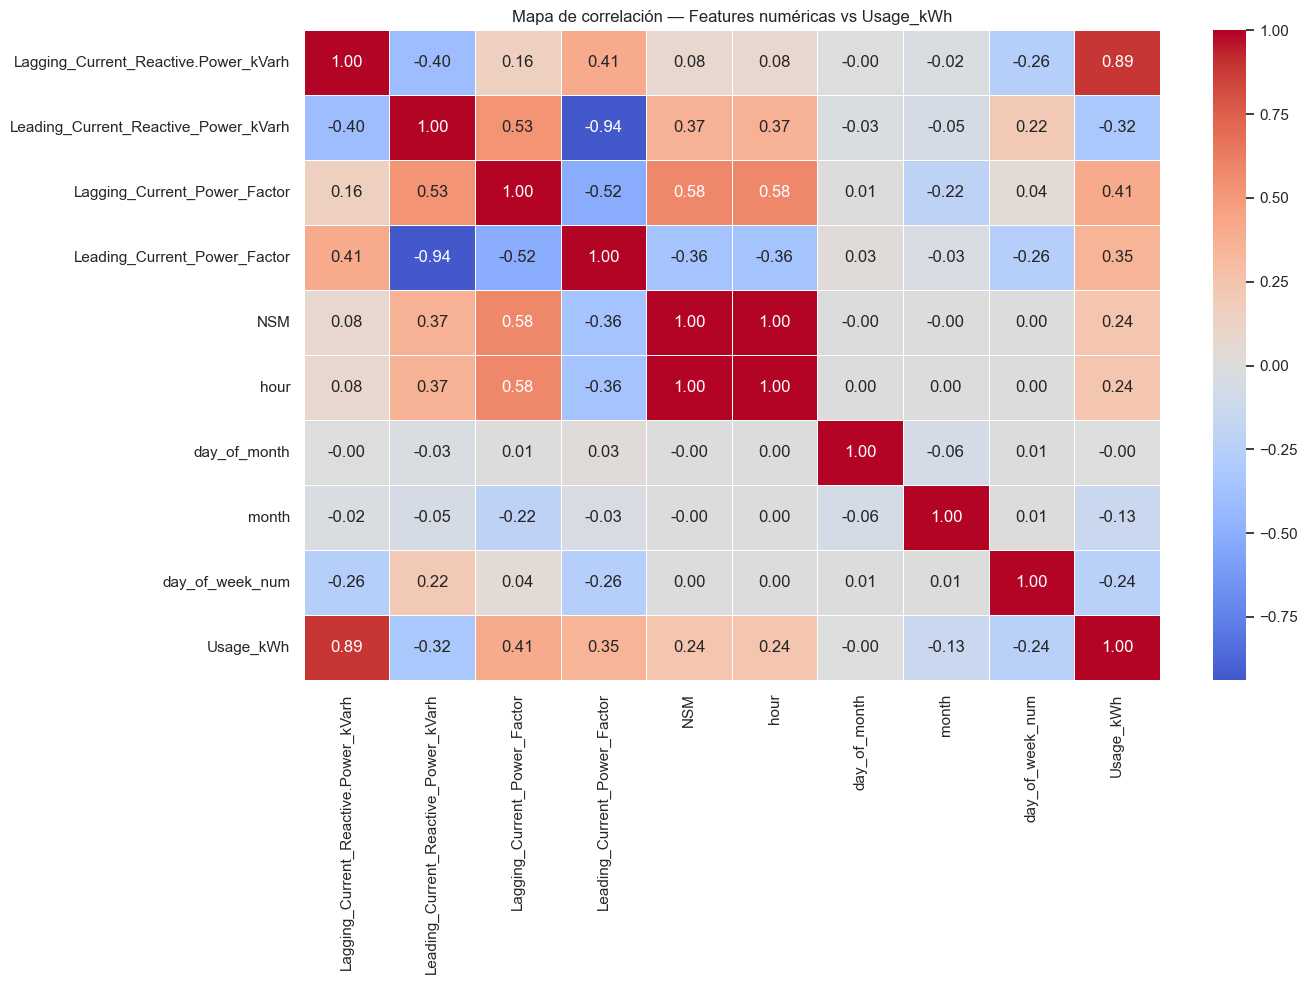

In [9]:
numerical_cols: list[str] = df.select_dtypes(include=[np.number]).columns.tolist()
numerical_cols = [c for c in numerical_cols if c != "Usage_kWh"]

corr_matrix: pd.DataFrame = df[numerical_cols + ["Usage_kWh"]].corr()

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    ax=ax,
    linewidths=0.5,
)
ax.set_title("Mapa de correlación — Features numéricas vs Usage_kWh")
plt.tight_layout()
plt.show()

In [10]:
corr_with_target: pd.Series = (
    corr_matrix["Usage_kWh"]
    .drop("Usage_kWh")
    .abs()
    .sort_values(ascending=False)
)

print("Correlación con Usage_kWh (ordenada por valor absoluto):")
print(corr_with_target.to_string())

top3_features: list[str] = corr_with_target.head(3).index.tolist()
print(f"\nTop 3 features más correlacionadas: {top3_features}")

Correlación con Usage_kWh (ordenada por valor absoluto):
Lagging_Current_Reactive.Power_kVarh    0.887901
Lagging_Current_Power_Factor            0.405838
Leading_Current_Power_Factor            0.354243
Leading_Current_Reactive_Power_kVarh    0.322711
day_of_week_num                         0.243970
NSM                                     0.240362
hour                                    0.239946
month                                   0.133690
day_of_month                            0.001367

Top 3 features más correlacionadas: ['Lagging_Current_Reactive.Power_kVarh', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor']


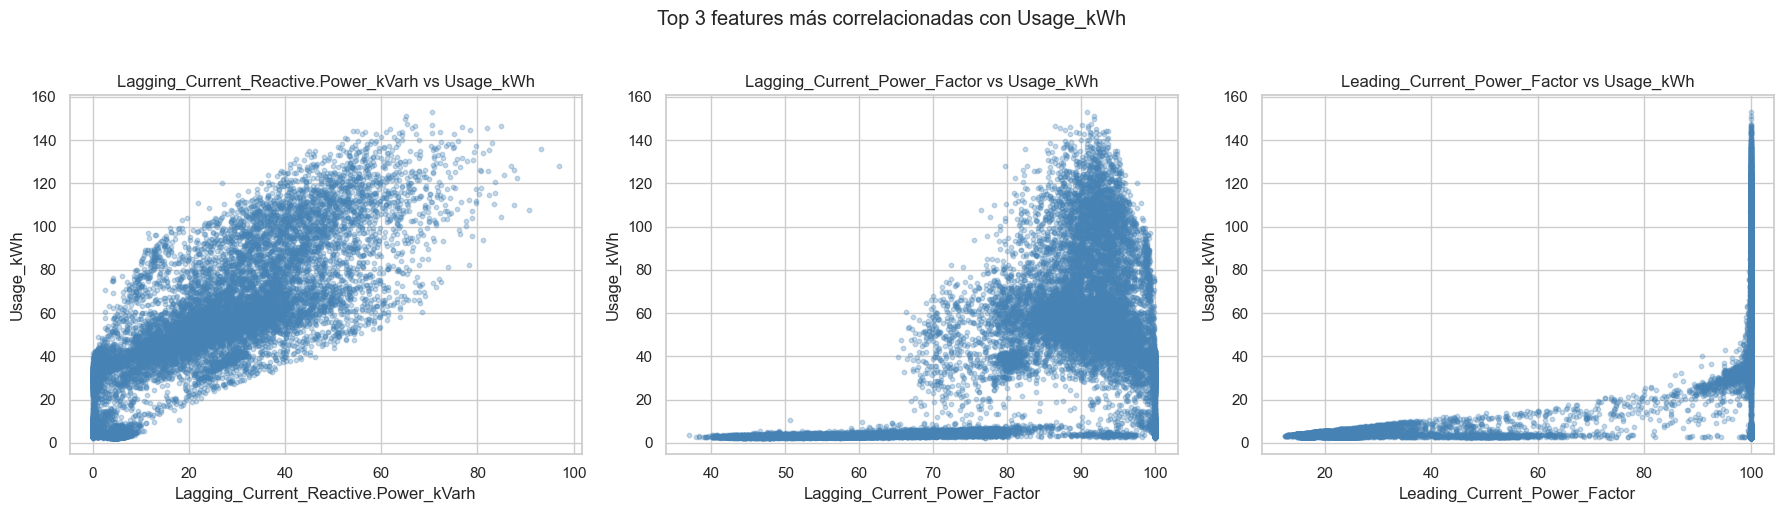

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, feature in enumerate(top3_features):
    axes[i].scatter(df[feature], df["Usage_kWh"], alpha=0.3, s=10, color="steelblue")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Usage_kWh")
    axes[i].set_title(f"{feature} vs Usage_kWh")

plt.suptitle("Top 3 features más correlacionadas con Usage_kWh", y=1.02)
plt.tight_layout()
plt.show()

---
## Sección 6 — Categorical Features Analysis

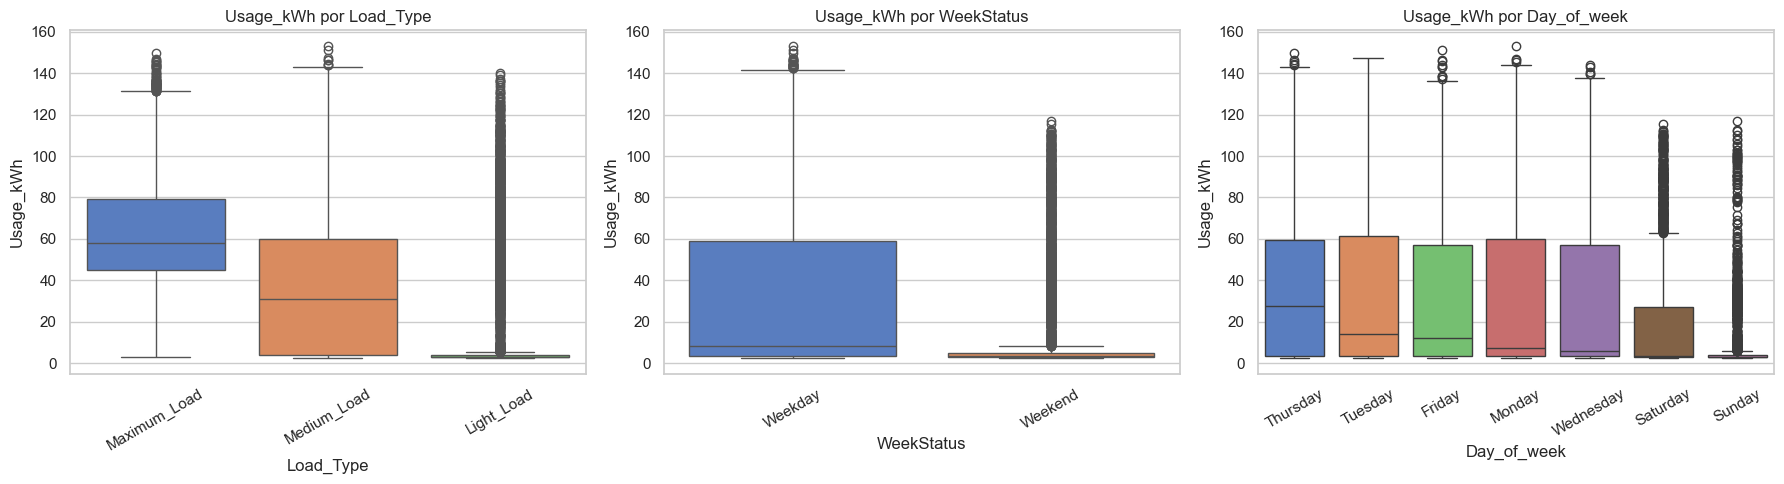

In [12]:
cat_features: list[str] = ["Load_Type", "WeekStatus", "Day_of_week"]
cat_features_present: list[str] = [c for c in cat_features if c in df.columns]

fig, axes = plt.subplots(1, len(cat_features_present), figsize=(6 * len(cat_features_present), 5))

if len(cat_features_present) == 1:
    axes = [axes]

for ax, col in zip(axes, cat_features_present):
    order = df.groupby(col)["Usage_kWh"].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x=col, y="Usage_kWh", order=order, ax=ax, palette="muted")
    ax.set_title(f"Usage_kWh por {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Usage_kWh")
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

---
## Sección 7 — Temporal Split Visualization

In [13]:
SPLIT_DATE: pd.Timestamp = pd.Timestamp("2018-10-20")

df_sorted: pd.DataFrame = df.sort_values("date").reset_index(drop=True)

df_train: pd.DataFrame = df_sorted[df_sorted["date"] < SPLIT_DATE]
df_val: pd.DataFrame = df_sorted[df_sorted["date"] >= SPLIT_DATE]

print(f"Train: {len(df_train)} filas ({df_train['date'].min().date()} → {df_train['date'].max().date()})")
print(f"Val:   {len(df_val)} filas ({df_val['date'].min().date()} → {df_val['date'].max().date()})")
print(f"Split: {len(df_train)/len(df_sorted)*100:.1f}% train / {len(df_val)/len(df_sorted)*100:.1f}% val")

Train: 28032 filas (2018-01-01 → 2018-10-19)
Val:   0 filas (NaT → NaT)
Split: 100.0% train / 0.0% val


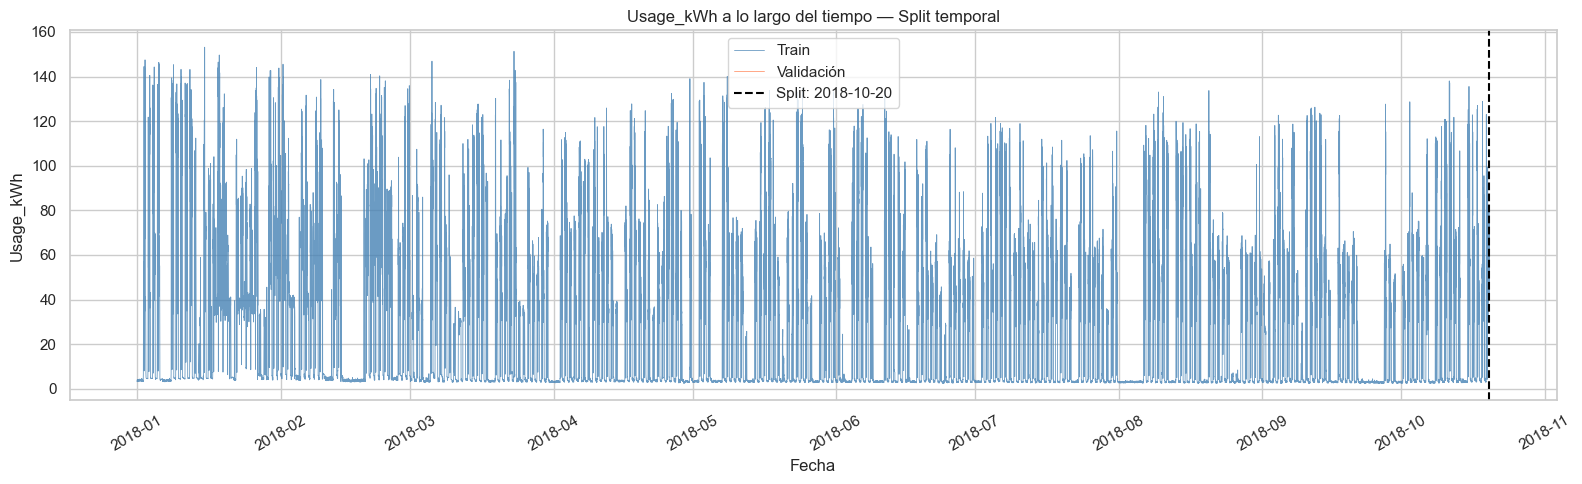

In [14]:
fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(
    df_train["date"], df_train["Usage_kWh"],
    color="steelblue", linewidth=0.6, label="Train", alpha=0.8,
)
ax.plot(
    df_val["date"], df_val["Usage_kWh"],
    color="coral", linewidth=0.6, label="Validación", alpha=0.8,
)
ax.axvline(SPLIT_DATE, color="black", linestyle="--", linewidth=1.5, label=f"Split: {SPLIT_DATE.date()}")

ax.set_title("Usage_kWh a lo largo del tiempo — Split temporal")
ax.set_xlabel("Fecha")
ax.set_ylabel("Usage_kWh")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

---
## Sección 8 — EDA Conclusions

### Features más predictivas

Las variables numéricas con mayor correlación lineal con `Usage_kWh` (ver Sección 5) son las mejores candidatas como punto de partida. Típicamente las potencias reactivas, la corriente y el factor de lagging/leading muestran alta correlación con el consumo total.

### Qué revela la columna `date`

- **Hora del día:** patrón diurno fuerte — consumo alto en horario laboral.
- **Día de semana / WeekStatus:** la planta opera distinto en fin de semana; `WeekStatus` es una feature de alta señal.
- **Mes:** variación estacional moderada, probablemente ligada a ciclos de producción.
- Recomendación: extraer `hour`, `month`, `day_of_week_num` y considerar codificación cíclica (sin/cos) para capturar la periodicidad sin romper la continuidad.

### Split temporal

El corte en octubre 2018 separa el ~80-90% inicial como train y el resto como validación. El perfil de consumo parece estacionario a lo largo del año, lo que da confianza en que el modelo generalizará bien a la ventana de validación.

### Recomendación para el pipeline

1. **Feature engineering:** extraer hora, mes, día de semana, codificación cíclica.
2. **Encoding:** `WeekStatus` y `Day_of_week` con `OrdinalEncoder` o `OneHotEncoder`; `Load_Type` con `OneHotEncoder`.
3. **Scaling:** `StandardScaler` o `RobustScaler` sobre features numéricas (hay outliers moderados).
4. **Modelo base:** `Ridge` o `GradientBoostingRegressor`; después probar `LightGBM`.
5. **Evaluación:** RMSE y R² sobre el split temporal — no usar shuffle-split para evitar data leakage.